In [1]:
import pandas as pd
from ctw.tree import Tree, view_tree, TreeNode, __visualize_tree
from ctw.models import Quantizer, LiveARTree
from matplotlib import pyplot as plt
import numpy as np

In [2]:
import pandas as pd

unemp_m = pd.read_csv(
    "https://fred.stlouisfed.org/graph/fredgraph.csv?id=UNRATE",
    parse_dates=["observation_date"],
    index_col="observation_date"
)

unemp_m = unemp_m.loc["1948-01-01":"2018-12-31"]

# use trimestrial means 
unemp_q = unemp_m.resample("QE").mean()

# applied the diff as in the paper 
unemp_diff = unemp_q.diff().dropna()

df = unemp_diff.copy()

<Axes: title={'center': 'US Unemployment Rate'}, xlabel='observation_date'>

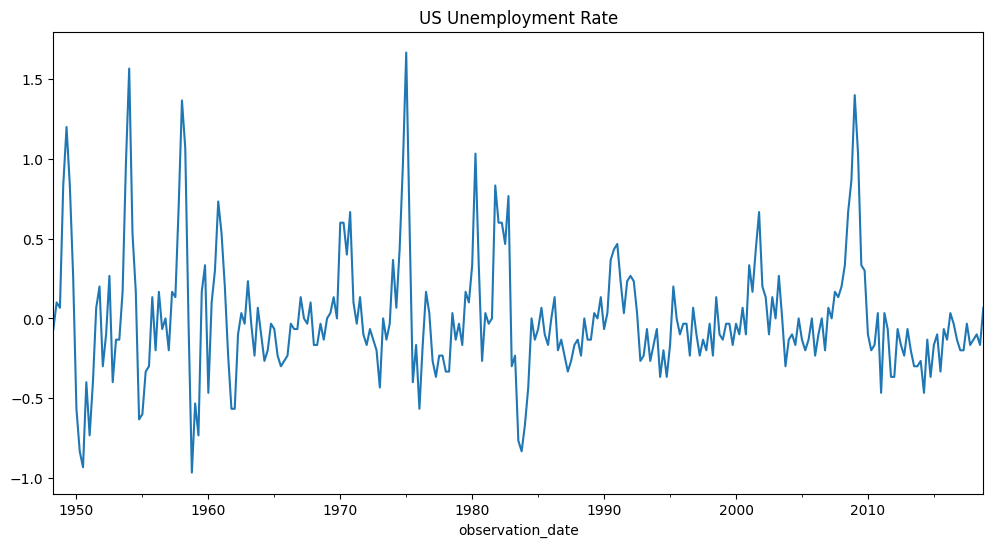

In [3]:
df['UNRATE'].plot(title='US Unemployment Rate', figsize=(12, 6))

(283,)
In-sample MSE (full dataset): 0.077584


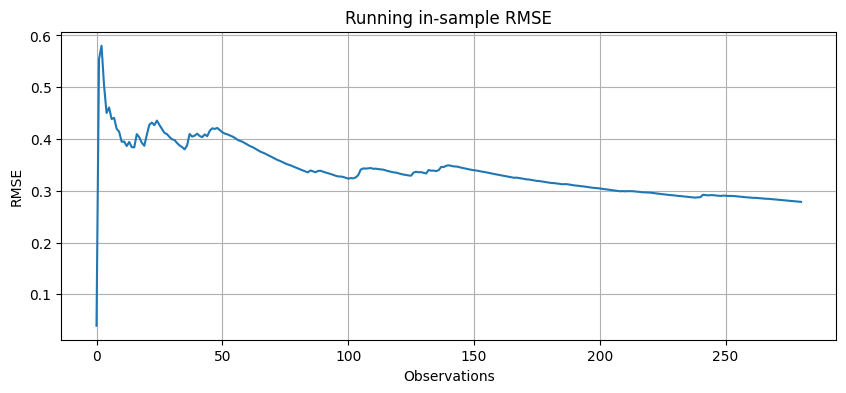

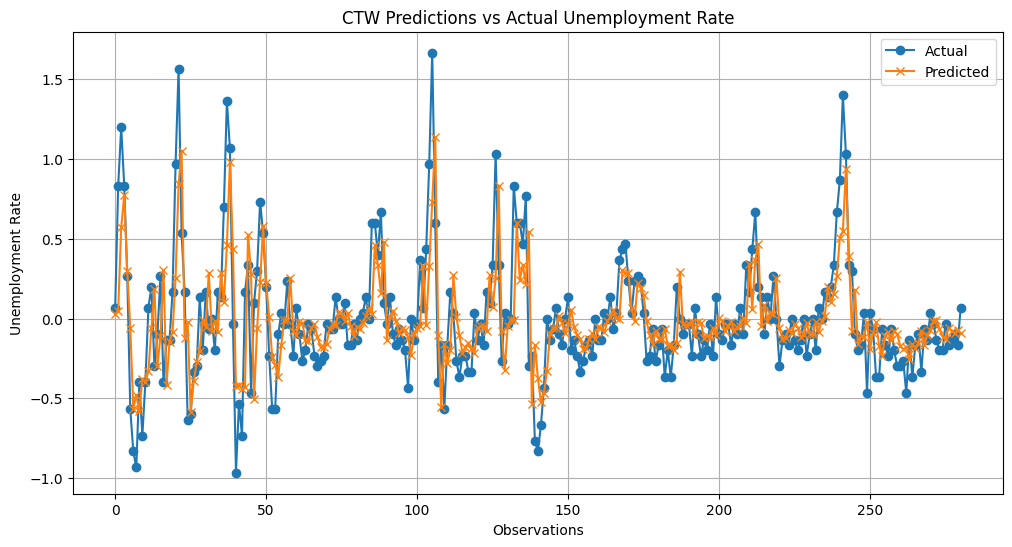

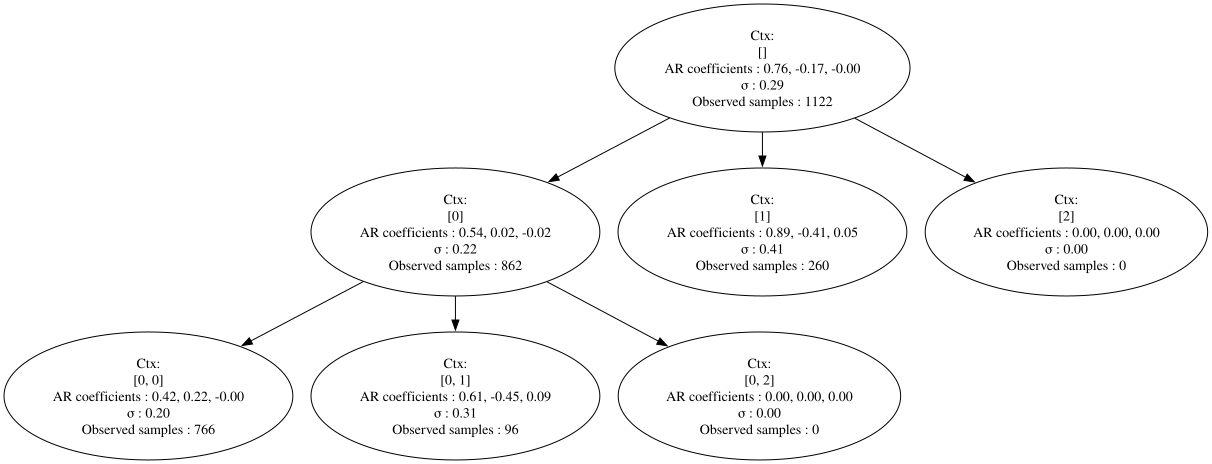

In [4]:
X = df["UNRATE"].dropna().to_numpy(dtype=float)
print(X.shape)

# Full-dataset in-sample evaluation (online one-step-ahead)
# Predict each point from its past, then update the model with that true value.
quantizer = Quantizer(thresholds=[0.15, 100])
ctw = LiveARTree(max_depth=2, order=2, constant_term=True, quantizer=quantizer, beta=0.5, tau=0.01, lambda_=0.01)

predictions = []
actuals = []

for i in range(4) :
    for t in range(2, len(X)):
        ctw.observe(X[t])

for t in range(2, len(X)):
    history = X[t - 2:t]
    pred = ctw.predict(history)
    predictions.append(pred)
    actuals.append(X[t])

predictions = np.asarray(predictions, dtype=float)
actuals = np.asarray(actuals, dtype=float)
mse = np.mean((actuals - predictions) ** 2)
print(f"In-sample MSE (full dataset): {mse:.6f}")

running_rmse = np.sqrt(np.cumsum((actuals - predictions) ** 2) / np.arange(1, len(actuals) + 1))
plt.figure(figsize=(10, 4))
plt.plot(running_rmse)
plt.title("Running in-sample RMSE")
plt.xlabel("Observations")
plt.ylabel("RMSE")
plt.grid(True)
plt.show()



## Plot predictions vs actuals
plt.figure(figsize=(12, 6))
plt.plot(actuals, label="Actual", marker='o')
plt.plot(predictions, label="Predicted", marker='x')
plt.title("CTW Predictions vs Actual Unemployment Rate")
plt.xlabel("Observations")
plt.ylabel("Unemployment Rate")
plt.legend()
plt.grid(True)
plt.show()

view_tree(ctw.tree)


In [5]:
## COmpute rmse of basic arma(2, 0) model for comparison
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(X, order=(5, 0, 0))
model_fit = model.fit()
predictions_arma = model_fit.predict(start=2, end=len(X)-1)
mse_arma = np.mean((X[2:] - predictions_arma) ** 2)
print(f"ARMA(2, 0) in-sample MSE: {mse_arma:.6f}")

ModuleNotFoundError: No module named 'statsmodels'

In [ ]:
## Fit SETAR model for comparison
